# Class 11: Review practice problems

A few review practice problems. Since we didn't get many questions on Canvas, I am basing this on questions students submitted in previous years.


In [ ]:
import YData

# YData.download.download_class_code(11)   # get class code    
# YData.download.download_class_code(11, True) # get the code with the answers 

YData.download_data("dow.csv")
YData.download_data("nba_salaries_2015_16.csv")
YData.download_data("daily_bike_totals.csv")
YData.download_data("gapminder_data.csv")

'gapminder_data.csv'

In [ ]:
import pandas as pd
import statistics
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
%matplotlib inline

# Worked examples

These are worked through together. Nothing here is an exercise — the code is all filled in, and the point is to read the output and see which command does what.

The practice problems start after these.

## A. Counting things: `len`, `.sum()` and `.count()`

Three different ways to get a number out of a column, and they do not answer the same question. One small table, with one missing value in it:

In [ ]:
scores = pd.DataFrame({
    "player": ["Ama", "Ben", "Cy", "Dee", "Eli"],
    "team":   ["Reds", "Reds", "Blues", "Blues", "Blues"],
    "points": [22, np.nan, 17, 31, 8],
})

scores

,player,team,points
0,Ama,Reds,22.0
1,Ben,Reds,NaN
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


In [ ]:
print("rows in the table:                ", len(scores))
print("points values that are present:   ", scores["points"].count())
print("points values that are missing:   ", scores["points"].isna().sum())
print("players who scored more than 15:  ", (scores["points"] > 15).sum())
print("the same, by filtering first:     ", len(scores[scores["points"] > 15]))

rows in the table:                 5
points values that are present:    4
points values that are missing:    1
players who scored more than 15:   3
the same, by filtering first:      3


What each one is doing:

- `len(scores)` counts **rows**. It does not care whether any value is missing, so it is 5.
- `scores["points"].count()` counts **values that are actually there**. Ben's points are missing, so it is 4.
- `scores["points"] > 15` is not a number — it is a column of `True` and `False`. Adding it up with `.sum()` treats `True` as 1 and `False` as 0, so the sum *is* the number of players who scored more than 15.
- Filtering first and then taking `len` gives the same answer. Both are fine; the comparison with `.sum()` is shorter.

If you want "how many players have a recorded score", `len` gives the wrong answer, because it counts Ben too.

In [ ]:
# A comparison against a missing value is False, so Ben is not counted either way.
display(scores["points"] > 15)
print("sum of that column:", (scores["points"] > 15).sum())

0     True
1    False
2     True
3     True
4    False
Name: points, dtype: bool

sum of that column: 3


## B. `groupby`

`groupby` splits the table into groups, then you say what to work out for each group. Here, per team:

In [ ]:
team_stats = scores.groupby("team").agg(
    players      = ("player", "count"),
    total_points = ("points", "sum"),
    mean_points  = ("points", "mean"),
)

team_stats

,players,total_points,mean_points
team,,,
Blues,3,56.0,18.666667
Reds,2,22.0,22.000000


Two things to notice.

The team name is now the **Index**, not a column. That is why `team_stats["team"]` would fail. `.reset_index()` turns it back into an ordinary column:

In [ ]:
team_stats.reset_index()

,team,players,total_points,mean_points
0,Blues,3,56.0,18.666667
1,Reds,2,22.0,22.000000


And the missing value is skipped inside the groups too. The Reds have two players, but only one recorded score, so `players` counts the `player` column and `mean_points` averages the one score that exists:

In [ ]:
scores.groupby("team").agg(
    players       = ("player", "count"),   # counts names, all present
    scores_given  = ("points", "count"),   # counts points, Ben's is missing
    mean_points   = ("points", "mean"),
)

,players,scores_given,mean_points
team,,,
Blues,3,3,18.666667
Reds,2,1,22.000000


In [ ]:
# scores.groupby("team").agg("mean"). # Why does this break?
scores[["team","points"]].groupby("team").agg("mean")
# scores[["team","points"]].groupby("team").agg(["mean","count"])


,points
team,
Blues,18.666667
Reds,22.000000


## C. Merging on a column, and how many rows you get

Two small tables about bike stations. Read them carefully before running the merges — the row counts come from what is and is not matched.

In [ ]:
rides = pd.DataFrame({
    "station": ["Broadway", "Broadway", "Chapel", "Elm", "Grove"],
    "trips":   [120, 95, 60, 25, 40],
})

info = pd.DataFrame({
    "station": ["Broadway", "Chapel", "Howe"],
    "docks":   [30, 18, 22],
})

display(rides)
display(info)

,station,trips
0,Broadway,120
1,Broadway,95
2,Chapel,60
3,Elm,25
4,Grove,40


,station,docks
0,Broadway,30
1,Chapel,18
2,Howe,22



- **Broadway appears twice** in `rides` and once in `info`.
- **Elm and Grove** are in `rides` but not in `info`.
- **Howe** is in `info` but not in `rides`.

Now the four joins:

In [ ]:
how = "inner"
result = rides.merge(info, on = "station", how = how)
print("%-6s -> %d rows" % ("inner", len(result)))
display(result)

how = "left"
result = rides.merge(info, on = "station", how = how)
print("%-6s -> %d rows" % (how, len(result)))
display(result)

how = "right"
result = rides.merge(info, on = "station", how = how)
print("%-6s -> %d rows" % (how, len(result)))
display(result)

how = "outer"
result = rides.merge(info, on = "station", how = how)
print("%-6s -> %d rows" % (how, len(result)))
display(result)

inner  -> 3 rows


,station,trips,docks
0,Broadway,120,30
1,Broadway,95,30
2,Chapel,60,18


left   -> 5 rows


,station,trips,docks
0,Broadway,120,30.0
1,Broadway,95,30.0
2,Chapel,60,18.0
3,Elm,25,NaN
4,Grove,40,NaN


right  -> 4 rows


,station,trips,docks
0,Broadway,120.0,30
1,Broadway,95.0,30
2,Chapel,60.0,18
3,Howe,NaN,22


outer  -> 6 rows


,station,trips,docks
0,Broadway,120.0,30.0
1,Broadway,95.0,30.0
2,Chapel,60.0,18.0
3,Elm,25.0,NaN
4,Grove,40.0,NaN
5,Howe,NaN,22.0


Where the numbers come from:

- `inner` keeps only stations in **both**: Broadway twice plus Chapel once.
- `left` keeps every row of `rides`, so all 5, with `docks` missing for Elm and Grove.
- `right` keeps every row of `info`: Broadway matched twice, Chapel once, Howe once with `trips` missing.
- `outer` keeps everything: the 5 rows of the left merge, plus a row for Howe.

Note the duplicates! A station listed twice on the left and once on the right produces **two** rows, not one. A merge can give you more rows than either table started with.

## D. Merging when the columns have different names

The matching columns do not have to share a name. Here one table calls it `pos` and the other calls it `code`, so `on =` will not work and you give `left_on` and `right_on` instead.

In [ ]:
players = pd.DataFrame({
    "player": ["Ama", "Ben", "Cy", "Dee"],
    "pos":    ["G", "F", "C", "X"],
})

positions = pd.DataFrame({
    "code":          ["G", "F", "C", "W"],
    "position_name": ["Guard", "Forward", "Center", "Wing"],
})

display(players)
display(positions)

,player,pos
0,Ama,G
1,Ben,F
2,Cy,C
3,Dee,X


,code,position_name
0,G,Guard
1,F,Forward
2,C,Center
3,W,Wing


Say you want to keep **every player**, even `Dee`, whose `"X"` matches nothing — and you do **not** want a row for `"W"`, which no player has. That is a left merge, with `players` on the left:

In [ ]:
players.merge(positions, left_on = "pos", right_on = "code", how = "left")

,player,pos,code,position_name
0,Ama,G,G,Guard
1,Ben,F,F,Forward
2,Cy,C,C,Center
3,Dee,X,NaN,NaN


Dee survives with a missing `position_name`, and Wing does not appear at all. Compare with `how = "outer"`, which adds Wing as a row with no player:

In [ ]:
players.merge(positions, left_on = "pos", right_on = "code", how = "outer")

,player,pos,code,position_name
0,Cy,C,C,Center
1,Ben,F,F,Forward
2,Ama,G,G,Guard
3,NaN,NaN,W,Wing
4,Dee,X,NaN,NaN


Notice you end up with **both** `pos` and `code` as columns, because they had different names. With `on = "station"` in the earlier example you got one column, not two.

## E. `join` uses the Index, `merge` uses columns

`.join()` matches on the **Index** rather than on a column. `set_index` is how you move a column into the Index:

In [ ]:
rides_indexed = rides.set_index("station")
info_indexed  = info.set_index("station")

display(rides_indexed)
display(info_indexed)

,trips
station,
Broadway,120
Broadway,95
Chapel,60
Elm,25
Grove,40


,docks
station,
Broadway,30
Chapel,18
Howe,22


In [ ]:
# join matches the two Indexes
display(rides_indexed.join(info_indexed))

# merge on the column gives the same information, with station as a column
display(rides.merge(info, on = "station", how = "left"))


# To make things complicated, this works - not important for the exams, unless you use join(... on = ....)
display(rides.join(info_indexed, on = "station", how = "left"))

# To make things complicated, this doesn't work
# display(rides_indexed.join(info, on = "station", how = "left"))

,trips,docks
station,,
Broadway,120,30.0
Broadway,95,30.0
Chapel,60,18.0
Elm,25,NaN
Grove,40,NaN


,station,trips,docks
0,Broadway,120,30.0
1,Broadway,95,30.0
2,Chapel,60,18.0
3,Elm,25,NaN
4,Grove,40,NaN


,station,trips,docks
0,Broadway,120,30.0
1,Broadway,95,30.0
2,Chapel,60,18.0
3,Elm,25,NaN
4,Grove,40,NaN


Same information, different shape: after `join` the station is the Index, after `merge` it is a column. `.join()` keeps all the left rows by default, which is why both show 5 rows here.

## F. Percentiles and z-scores

Two ways of saying where one value sits inside a column. Both are one line, and both came up in class 6 and Homework 3.

### Percentiles

`np.percentile(data, 90)` gives the value that 90% of the data falls below. Missing values break it, so drop them first:

In [ ]:
print("straight at the column, which still has Ben's missing score:")
print("   np.percentile(scores['points'], 90) =", np.percentile(scores["points"], 90))

points = scores["points"].dropna()
print("after .dropna():")
print("   the 90th percentile =", np.percentile(points, 90))

straight at the column, which still has Ben's missing score:
   np.percentile(scores['points'], 90) = nan
after .dropna():
   the 90th percentile = 28.3


A `nan` answer from `np.percentile` almost always means a missing value in the column, not a mistake in your code.

The median is the 50th percentile, which is a useful sanity check that you have the arguments the right way round:

In [ ]:
print("np.median(points)           =", np.median(points))
print("np.percentile(points, 50)   =", np.percentile(points, 50))

np.median(points)           = 19.5
np.percentile(points, 50)   = 19.5


### z-scores

A z-score says how many standard deviations a value is above or below the mean:

$$z = \frac{\text{value} - \text{mean}}{\text{standard deviation}}$$

Worked out with the functions class 4 and class 6 used:

In [ ]:
mean_points = statistics.mean(points)
sd_points   = statistics.stdev(points)

print("mean:", round(mean_points, 3), "  sd:", round(sd_points, 3))

ama = scores.loc[scores["player"] == "Ama", "points"].iloc[0]
print("Ama scored", ama, "-> z =", round((ama - mean_points) / sd_points, 3))

mean: 19.5   sd: 9.609
Ama scored 22.0 -> z = 0.26


A whole column at once, which is the shape you usually want — subtract the mean, divide by the standard deviation:

In [ ]:
z_table = scores.copy()
z_table["points_z"] = (z_table["points"] - mean_points) / sd_points

z_table

,player,team,points,points_z
0,Ama,Reds,22.0,0.260172
1,Ben,Reds,NaN,NaN
2,Cy,Blues,17.0,-0.260172
3,Dee,Blues,31.0,1.196792
4,Eli,Blues,8.0,-1.196792


Ben's z-score is missing, because his score was. Everything else is positive or negative according to whether it beat the mean.

#### Sample or population — they give different answers

This course has used both, and they are **not** the same number:

In [ ]:
print("statistics.stdev(points)        =", round(statistics.stdev(points), 4), " <- sample, divides by n-1")
print("points.std()                    =", round(points.std(), 4), " <- pandas, sample as well")
print("np.std(points)                  =", round(np.std(points), 4), " <- population, divides by n")
print("np.std(points, ddof = 1)        =", round(np.std(points, ddof = 1), 4), " <- numpy, made to match the sample one")

statistics.stdev(points)        = 9.609  <- sample, divides by n-1
points.std()                    = 9.609  <- pandas, sample as well
np.std(points)                  = 8.3217  <- population, divides by n
np.std(points, ddof = 1)        = 9.609  <- numpy, made to match the sample one


`statistics.stdev` and pandas' `.std()` both use the sample convention. `np.std` uses the population one unless you pass `ddof = 1`.

If a question asks for the **sample** standard deviation, use `statistics.stdev`, `.std()`, or `np.std(..., ddof = 1)`. Reaching for plain `np.std` gives a different answer.

## G. What changes your data, and what does not

Most commands hand you back a **new** thing and leave the original alone. A few change the original. Mixing the two up is how people lose work, so it is worth being able to tell them apart.

A useful one-way test: **if a command hands you back `None`, it changed the original** — so assigning its result is a mistake. The reverse is not a rule. A few commands do both: they change the original *and* hand something back. `df.pop("col")` removes a column and gives you it. None of those appear in this course, but do not treat "it gave me something back" as proof that your data is safe.

DataFrames and lists both have this split, but they **spell it differently** — so they are below as two separate parts, and part G3 says why you cannot carry a habit from one to the other.

### G1. DataFrames

Our table, with Ben's score missing:

In [ ]:
demo = scores.copy()
demo

,player,team,points
0,Ama,Reds,22.0
1,Ben,Reds,NaN
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


#### These hand you a new table and leave `demo` alone

Watch both: the result comes out sorted, and `demo` underneath it is still in the original order.

In [ ]:
print("what demo.sort_values(\"points\") gives you:")
display(demo.sort_values("points"))

print("demo itself, afterwards:")
display(demo)

what demo.sort_values("points") gives you:


,player,team,points
4,Eli,Blues,8.0
2,Cy,Blues,17.0
0,Ama,Reds,22.0
3,Dee,Blues,31.0
1,Ben,Reds,NaN


demo itself, afterwards:


,player,team,points
0,Ama,Reds,22.0
1,Ben,Reds,NaN
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


`dropna` is the same. The result has Ben's row removed; `demo` still has it.

In [ ]:
print("what demo.dropna() gives you -- 4 rows:")
display(demo.dropna())

print("demo itself, afterwards -- still 5 rows, Ben still there:")
display(demo)

what demo.dropna() gives you -- 4 rows:


,player,team,points
0,Ama,Reds,22.0
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


demo itself, afterwards -- still 5 rows, Ben still there:


,player,team,points
0,Ama,Reds,22.0
1,Ben,Reds,NaN
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


#### Two ways to make the change stick

**One: assign the result to a name.** The original is still untouched; you just have the new table as well.

In [ ]:
sorted_demo = demo.sort_values("points")

print("sorted_demo:")
display(sorted_demo)
print("demo -- still the original order:")
display(demo)

sorted_demo:


,player,team,points
4,Eli,Blues,8.0
2,Cy,Blues,17.0
0,Ama,Reds,22.0
3,Dee,Blues,31.0
1,Ben,Reds,NaN


demo -- still the original order:


,player,team,points
0,Ama,Reds,22.0
1,Ben,Reds,NaN
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


**Two: `inplace = True`.** This is what "in place" means — change this table where it stands, rather than making a new one. This is the form we used on the movies data in class 4 and class 6.

In [ ]:
cleaned = scores.copy()

print("cleaned, before:")
display(cleaned)

cleaned.dropna(inplace = True)          # changes cleaned itself

print("cleaned, after dropna(inplace = True) -- Ben is gone for good:")
display(cleaned)

cleaned, before:


,player,team,points
0,Ama,Reds,22.0
1,Ben,Reds,NaN
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


cleaned, after dropna(inplace = True) -- Ben is gone for good:


,player,team,points
0,Ama,Reds,22.0
2,Cy,Blues,17.0
3,Dee,Blues,31.0
4,Eli,Blues,8.0


#### The return value is usually the tell

A command that makes a new table hands it to you. A command that worked in place hands you `None`.

In [ ]:
check = scores.copy()

print("type of what dropna() gives back:        ", type(check.dropna()).__name__)
print("what dropna(inplace = True) gives back:  ", check.dropna(inplace = True))

type of what dropna() gives back:         DataFrame
what dropna(inplace = True) gives back:   None


That second line is the trap. Because `inplace = True` returns `None`, writing

```
check = check.dropna(inplace = True)
```

sets `check` to `None` and your table is gone. Use one style or the other, never both:

In [ ]:
oops = scores.copy()
oops = oops.dropna(inplace = True)      # both styles at once -- do not do this
print("oops is now:", oops)

oops is now: None


#### Changing a column always changes the table

There is no "new table" version of this. Assigning to a column, by name or through `.loc`, changes the table you are working on. Class 10 used the `.loc` form.

In [ ]:
demo["double_points"] = demo["points"] * 2
demo.loc[demo["points"] > 20, "big_scorer"] = True

demo

,player,team,points,double_points,big_scorer
0,Ama,Reds,22.0,44.0,True
1,Ben,Reds,NaN,NaN,NaN
2,Cy,Blues,17.0,34.0,NaN
3,Dee,Blues,31.0,62.0,True
4,Eli,Blues,8.0,16.0,NaN


#### `a = demo` is not a copy

This one catches everybody. It does not make a second table — it gives the same table a second name, so a change through either name shows up in both.

In [ ]:
a = demo                 # same table, second name
a["from_a"] = 1          # really a change to demo

print("demo columns:", list(demo.columns))

demo columns: ['player', 'team', 'points', 'double_points', 'big_scorer', 'from_a']


In [ ]:
b = demo.copy()          # a genuinely separate table
b["from_b"] = 1          # demo is not affected

print("b columns:   ", list(b.columns))
print("demo columns:", list(demo.columns))

b columns:    ['player', 'team', 'points', 'double_points', 'big_scorer', 'from_a', 'from_b']
demo columns: ['player', 'team', 'points', 'double_points', 'big_scorer', 'from_a']


Taking a subset first is safe — changing the subset does not reach back into the original. This holds whether you subset **rows**:

In [ ]:
subset = demo[demo["points"] > 15]
subset["checked"] = True

print("subset columns:", list(subset.columns))
print("demo columns:  ", list(demo.columns))

subset columns: ['player', 'team', 'points', 'double_points', 'big_scorer', 'from_a', 'checked']
demo columns:   ['player', 'team', 'points', 'double_points', 'big_scorer', 'from_a']


…or **columns**. Pick some columns, give them a new name, change whatever you like there and the *original* is *untouched*. That is true both for adding a new column (to the subset) and for overwriting one that already exists:

In [ ]:
just_two = demo[["player", "points"]]      # a column subset, under a new name

just_two["flag"] = 1                      # a new column
just_two["points"] = 0                    # overwriting an existing one

print("just_two columns:", list(just_two.columns))
print("just_two points: ", list(just_two["points"]))
print()
print("demo columns:", list(demo.columns))
print("demo points: ", list(demo["points"]), "-- untouched")

just_two columns: ['player', 'points', 'flag']
just_two points:  [0, 0, 0, 0, 0]

demo columns: ['player', 'team', 'points', 'double_points', 'big_scorer', 'from_a']
demo points:  [22.0, nan, 17.0, 31.0, 8.0] -- untouched


The same goes for a single column pulled out as a Series:

In [ ]:
one_col = demo["points"]       # a Series
one_col.iloc[0] = 999          # change it

print("one_col:", list(one_col))
print("demo:   ", list(demo["points"]), " still untouched")

one_col: [999.0, nan, 17.0, 31.0, 8.0]
demo:    [22.0, nan, 17.0, 31.0, 8.0]  still untouched


This is worth knowing because it **used to be different**. Older pandas would sometimes give you **a view** onto the original instead of a copy, and changing it would either alter the original or raise a `SettingWithCopyWarning` telling you it might. From pandas 3 onwards a subset is always its own thing, so the warning is gone and this is simply safe.

The thing that is *not* safe is the one with no subsetting in it at all: `a = demo`, above. That is not a subset, it is a second name for the same table.

| DataFrame | changes the original? |
|---|---|
| `df.sort_values(...)`, `df.dropna()`, `df.rename(...)`, `df.reset_index()`, `df[df["x"] > 1]`, `df.head()` | no — you get a new table back |
| the same methods with `inplace = True` | **yes** — and you get `None` back |
| `df["new"] = ...`, `df.loc[mask, "new"] = ...` | **yes** |
| `new_name = df.sort_values(...)` | no — `df` is untouched, you just also have `new_name` |
| `a = df` | no new table at all — one table, two names |
| `a = df.copy()` | a separate table, safe to change |

### G2. Lists

A list has the same split, but you choose between **two different commands** rather than setting an argument.

In [ ]:
nums = [3, 1, 2]

print("sorted(nums) gives:", sorted(nums))
print("and nums is still:  ", nums)

sorted(nums) gives: [1, 2, 3]
and nums is still:   [3, 1, 2]


In [ ]:
nums.sort()                  # sorts the list in place
print("after nums.sort(), nums is:", nums)

after nums.sort(), nums is: [1, 2, 3]


The same return-value test works here. `sorted()` hands you a new list; `.sort()` hands you `None`.

In [ ]:
print("type of what sorted() gives back:", type(sorted([3, 1, 2])).__name__)
print("what .sort() gives back:          ", [3, 1, 2].sort())

type of what sorted() gives back: list
what .sort() gives back:           None


So `nums = nums.sort()` throws your list away and leaves you with `None` — the list version of the same trap:

In [ ]:
oops_list = [3, 1, 2]
oops_list = oops_list.sort()
print("oops_list is now:", oops_list)

oops_list is now: None


| list | changes the original? |
|---|---|
| `sorted(my_list)` | no — you get a new list back |
| `my_list.sort()` | **yes** — and you get `None` back |
| `my_list.append(x)` | **yes** |
| `my_list[0] = x` | **yes** |

### G3. Recap: these commands for lists and DataFrames are a little different.

The **idea** is the same in both: something gives you a new object, something changes the original, and the return value tells you which. The **spelling is different**, and the names do not carry across.

- A **list** gives you two separate commands: `sorted(x)` makes a new list, `x.sort()` changes `x`. There is no `inplace` argument anywhere.
- A **DataFrame** gives you one method with a switch: `df.sort_values()` makes a new table, `df.sort_values(inplace = True)` changes `df`. There is no `.sort()` method at all.

Each of these is a mistake, and the error message tells you which world you are in:

In [ ]:
nums = [3, 1, 2]

for label, action in [
    ("df.sort()",             lambda: demo.sort()),
    ("my_list.sort_values()", lambda: nums.sort_values()),
    ("my_list.sort(inplace = True)", lambda: nums.sort(inplace = True)),
]:
    try:
        action()
    except Exception as e:
        print("%-31s -> %s: %s" % (label, type(e).__name__, e))

df.sort()                       -> AttributeError: 'DataFrame' object has no attribute 'sort'
my_list.sort_values()           -> AttributeError: 'list' object has no attribute 'sort_values'
my_list.sort(inplace = True)    -> TypeError: 'inplace' is an invalid keyword argument for sort()


And one that does *not* raise an error, which makes it worse. `sorted()` works on a DataFrame, but it does not sort it — it goes through the column names, so you get those back:

In [ ]:
print("sorted(demo) gives:", sorted(demo))

sorted(demo) gives: ['big_scorer', 'double_points', 'from_a', 'player', 'points', 'team']


On a Series, `sorted()` does return the values in order, but as a plain list — the Index is thrown away:

In [ ]:
points_series = scores.set_index("player")["points"]
display(points_series)

print("sorted(points_series) ->", sorted(points_series.dropna()))
print("type:", type(sorted(points_series.dropna())).__name__, "-- the player names are gone")

player
Ama    22.0
Ben     NaN
Cy     17.0
Dee    31.0
Eli     8.0
Name: points, dtype: float64

sorted(points_series) -> [8.0, 17.0, 22.0, 31.0]
type: list -- the player names are gone


| | make a new one | change the original |
|---|---|---|
| list | `sorted(my_list)` | `my_list.sort()` |
| DataFrame | `df.sort_values("col")` | `df.sort_values("col", inplace = True)` |

Crossing them over does not work: there is no `df.sort()`, no `my_list.sort_values()`, and no `inplace` argument on a list. Use `sorted()` on a DataFrame and you get its column names, with no error to warn you.

## H. The different kinds of variable we have used

Six containers, and the differences matter mostly when you try to do arithmetic or ask for an element.

In [ ]:
my_list   = [3, 1, 2]
my_tuple  = (3, 1, 2)
my_dict   = {"Ama": 22, "Ben": 17, "Cy": 31}
my_array  = np.array([3, 1, 2])
my_series = pd.Series([3, 1, 2], index = ["Ama", "Ben", "Cy"])
my_frame  = pd.DataFrame({"points": [3, 1, 2]}, index = ["Ama", "Ben", "Cy"])

for thing in [my_list, my_tuple, my_dict, my_array, my_series, my_frame]:
    print(type(thing))

<class 'list'>
<class 'tuple'>
<class 'dict'>
<class 'numpy.ndarray'>
<class 'pandas.Series'>
<class 'pandas.DataFrame'>


### Arithmetic is the big one

Multiplying a list repeats it. Multiplying an array or a Series multiplies every element:

In [ ]:
print("list  * 2 ->", my_list * 2)
print("tuple * 2 ->", my_tuple * 2)
print("array * 2 ->", my_array * 2)
print("series * 2 ->")
print(my_series * 2)

list  * 2 -> [3, 1, 2, 3, 1, 2]
tuple * 2 -> (3, 1, 2, 3, 1, 2)
array * 2 -> [6 2 4]
series * 2 ->
Ama    6
Ben    2
Cy     4
dtype: int64


### Getting one element out

In [ ]:
print("list, by position:          ", my_list[0])
print("tuple, by position:         ", my_tuple[0])
print("dictionary, by key:         ", my_dict["Ama"])
print("array, by position:         ", my_array[0])
print("Series, by Index label:     ", my_series["Ama"])
print("Series, by position:        ", my_series.iloc[0])
print("DataFrame, a whole column:  ")
print(my_frame["points"])

list, by position:           3
tuple, by position:          3
dictionary, by key:          22
array, by position:          3
Series, by Index label:      3
Series, by position:         3
DataFrame, a whole column:  
Ama    3
Ben    1
Cy     2
Name: points, dtype: int64


### A tuple cannot be changed after you make it

In [ ]:
my_list[0] = 99          # fine
print("list after assignment:", my_list)

try:
    my_tuple[0] = 99     # raises
except TypeError as e:
    print("tuple:", e)

list after assignment: [99, 1, 2]
tuple: 'tuple' object does not support item assignment


| | ordered? | can you change it? | how you get an element | arithmetic on the whole thing |
|---|---|---|---|---|
| `list` | yes | yes | position, `x[0]` | `* 2` repeats the list |
| `tuple` | yes | **no** | position, `x[0]` | `* 2` repeats the tuple |
| `dict` | by insertion | yes | **key**, `x["Ama"]` | no |
| `np.array` | yes | yes | position, `x[0]` | **element by element** |
| `pd.Series` | yes | yes | label `x["Ama"]` or position `x.iloc[0]` | **element by element** |
| `pd.DataFrame` | yes | yes | column `x["points"]`, then as a Series | element by element, per column |

A Series is the one with two ways in: it has an Index of labels **and** positions. That is the whole reason `.loc` and `.iloc` both exist.

A DataFrame is a set of Series sharing one Index — which is why pulling out a single column gives you a Series.

### And one row?

Pulling out a column gives a Series. Pulling out a row usually does too — a Series indexed by the column names:

In [ ]:
prices = pd.DataFrame({"item":  ["mug", "pen", "book"],
                       "price": [8.0, 2.0, 15.0]},
                      index = ["a", "b", "c"])
display(prices)

print("type of prices.loc[\"b\"]:", type(prices.loc["b"]).__name__)
prices.loc["b"]

,item,price
a,mug,8.0
b,pen,2.0
c,book,15.0


type of prices.loc["b"]: Series


item     pen
price    2.0
Name: b, dtype: object

But only if that label appears once. Give the same table a repeated label, and the **same call** hands back a DataFrame:

In [ ]:
repeated = pd.DataFrame({"item":  ["mug", "pen", "book"],
                         "price": [8.0, 2.0, 15.0]},
                        index = ["a", "b", "b"])
display(repeated)

print("type of repeated.loc[\"b\"]:", type(repeated.loc["b"]).__name__)
repeated.loc["b"]

,item,price
a,mug,8.0
b,pen,2.0
b,book,15.0


type of repeated.loc["b"]: DataFrame


,item,price
b,pen,2.0
b,book,15.0


You have already seen both.

- In **class 8**, `flights.loc["N25201"]` gave back several rows — one aircraft flies many flights, so the tail number repeats in the Index.
- In **class 9**, `open_and_close.loc["2023-08-16"]` gave back a Series — each date appears once.

So the shape you get depends on the **data**, not on the line you wrote. That is unusual, and it is worth remembering rather than trying to work out under time pressure.

`.iloc` never has this problem. Positions are always unique, so `.iloc[0]` is always one row, and always a Series:

In [ ]:
print("prices.iloc[0]   ->", type(prices.iloc[0]).__name__)
print("repeated.iloc[0] ->", type(repeated.iloc[0]).__name__)

prices.iloc[0]   -> Series
repeated.iloc[0] -> Series


## Practice problem 1

Using the `nba_salaries` data, create a data frame called `team_count` that displays the following columns:

1. `TEAM`: The team name of each NBA player represented.
2. `num_players`: The number of players on each team.


In [ ]:
nba = pd.read_csv("nba_salaries_2015_16.csv")

nba.groupby("TEAM").agg(num_players = ("PLAYER", "count")).reset_index()

,TEAM,num_players
0,Atlanta Hawks,14
1,Boston Celtics,15
2,Brooklyn Nets,13
3,Charlotte Hornets,18
4,Chicago Bulls,12
5,Cleveland Cavaliers,10
6,Dallas Mavericks,11
7,Denver Nuggets,14
8,Detroit Pistons,10
9,Golden State Warriors,14


## Practice problem 2

Suppose the data on the DOW Jones Industrial Average was loading in Python as a DataFrame in the name `dow`. Use Boolean masking to create a DataFrame that extracts data from all "Fridays". Save this to `dow_fridays`. Then, sort this new dataframe by `Open` values.



In [ ]:
dow = pd.read_csv("dow.csv")
dow = dow.set_index("Date")


dow_fridays = dow[dow["Day"] == "Friday"]
dow_fridays.sort_values("Open")

,Year,Month,Day,Open,High,Low,Close,Volume
Date,,,,,,,,
1992-01-03,1992,1,Friday,3172.399902,3210.639893,3165.919922,3201.500000,23620000
1992-10-16,1992,10,Friday,3174.699951,3180.350098,3142.530029,3174.399902,40880000
1992-10-09,1992,10,Friday,3176.000000,3176.300049,3131.719971,3136.600098,19310000
1992-10-23,1992,10,Friday,3200.899902,3215.199951,3196.020020,3207.600098,26490000
1992-03-13,1992,3,Friday,3208.600098,3237.030029,3208.179932,3235.899902,16370000
...,...,...,...,...,...,...,...,...
2024-01-05,2024,1,Friday,37455.460938,37623.621094,37323.820312,37466.109375,299480000
2024-01-19,2024,1,Friday,37572.500000,37933.730469,37451.710938,37863.800781,377650000
2023-12-29,2023,12,Friday,37701.628906,37759.429688,37538.800781,37689.539062,234570000


## Practice problem 3

Now show the distribution of the opening price of the DOW.


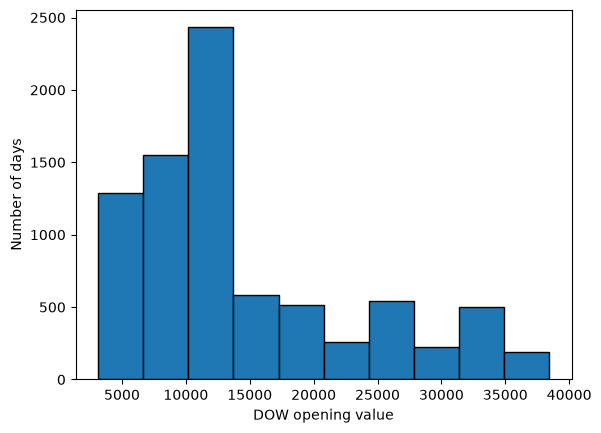

In [ ]:
plt.hist(dow["Open"], edgecolor = "k");
plt.xlabel("DOW opening value");
plt.ylabel("Number of days");


## Practice problem 4

The code below loads data on the number of bike trips taken each date on NYC citibikes, and also weather information.

Use this data to make a plot that shows the relationship between the wind speed on a given date and the number of bike rides taken.

Also, calculate the correlation between wind speed and the number of bike trips taken on each date.


In [ ]:
import statistics
bikes = pd.read_csv("daily_bike_totals.csv")
bikes.head(3)

,date,trips,precipitation,snow_depth,snowfall,max_temperature,min_temperature,average_wind_speed,dow,year,month,holiday,stations_in_service,weekday,weekday_non_holiday
0,2013-07-01,16650,0.838583,0.0,0.0,77.00,71.96,3.13171,1,2013,7,False,NaN,True,True
1,2013-07-02,22745,0.078740,0.0,0.0,82.04,71.96,2.68432,2,2013,7,False,NaN,True,True
2,2013-07-03,21864,0.531496,0.0,0.0,82.94,73.04,4.25018,3,2013,7,False,NaN,True,True


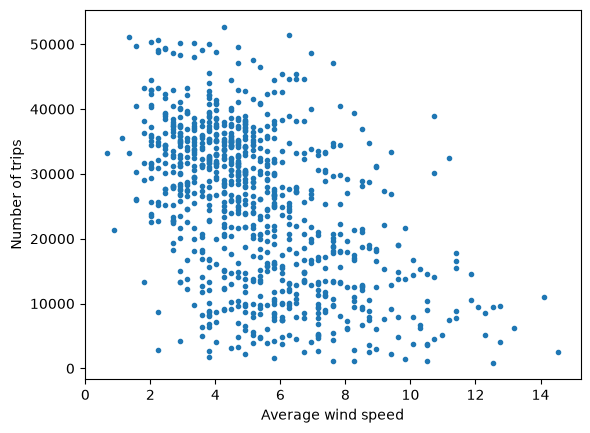

In [ ]:
plt.plot(bikes["average_wind_speed"], bikes["trips"], ".");
plt.xlabel("Average wind speed");
plt.ylabel("Number of trips");


In [ ]:
statistics.correlation(bikes["average_wind_speed"], bikes["trips"])

nan

In [ ]:
### ooopppsss! What went wrong?
bikes = bikes.dropna()
statistics.correlation(bikes["average_wind_speed"], bikes["trips"])

-0.5003417231285866

## Practice problem 5

Now, let's try to look at the relationship between the Dow close and the number of bike trips.

First, we have to merge the two datasets:

In [ ]:
dow_bikes = dow.reset_index().merge(bikes, left_on = "Date", right_on = "date")

Then we can calculate the correlation and make a scatterplot.

-0.08833424105049313


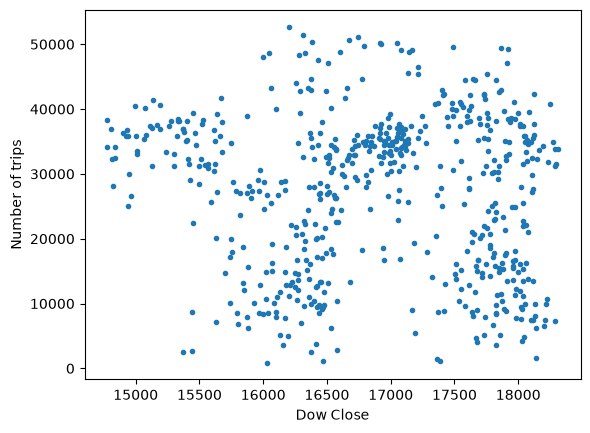

In [ ]:
plt.plot(dow_bikes["Close"], dow_bikes["trips"], ".");
plt.xlabel("Dow Close");
plt.ylabel("Number of trips");

print(statistics.correlation(dow_bikes["Close"], dow_bikes["trips"]))

## Practice problem 6


Consider the following code, in which lines from Taylor Swift's "Love Story" are interspersed in William Shakespeare's Romeo and Juliet:


<pre>

lines =  ["Two households, both alike in dignity,",
          "On a balcony in summer air",
          "In fair Verona, where we lay our scene,",
          "See the lights, see the party, the ball gowns",
          "From ancient grudge break to new mutiny,",
          "See you make your way through the crowd",
          "Where civil blood makes civil hands unclean.",
          "And say, 'Hello'",
          "From forth the fatal loins of these two foes",
          "Little did I know",
          "A pair of star-cross'd lovers take their life;",
          "That you were Romeo, you were throwin' pebbles",
          "Whose misadventured piteous overthrows",
          "And my daddy said, 'Stay away from Juliet'",
          "Do with their death bury their parents' strife.",
          "And I was cryin' on the staircase",
          "The fearful passage of their death-mark'd love,",
          "Beggin' you, 'Please don't go,' and I said",
          "And the continuance of their parents' rage,",
          "'Romeo, take me somewhere we can be alone'",
          "Which, but their children's end, nought could remove,",
          "'I'll be waiting, all there's left to do is run'",
          "Is now the two hours' traffic of our stage;",
          "You'll be the prince and I'll be the princess",
          "The which if you with patient ears attend,",
          "It's a love story, baby, just say, 'Yes'",
          "What here shall miss, our toil shall strive to mend."]
                          
</pre>

If I wanted to print ONLY the text from Romeo and Juliet, I could code the following: `lines[_:_:_]`

Which numbers belong in the blanks above

a) 1, 14, 2

b) 0, 27, 2

c) 1, 27, 4

d) 0, 14, 4



In [ ]:

lines =  ["Two households, both alike in dignity,",
          "On a balcony in summer air",
          "In fair Verona, where we lay our scene,",
          "See the lights, see the party, the ball gowns",
          "From ancient grudge break to new mutiny,",
          "See you make your way through the crowd",
          "Where civil blood makes civil hands unclean.",
          "And say, 'Hello'",
          "From forth the fatal loins of these two foes",
          "Little did I know",
          "A pair of star-cross'd lovers take their life;",
          "That you were Romeo, you were throwin' pebbles",
          "Whose misadventured piteous overthrows",
          "And my daddy said, 'Stay away from Juliet'",
          "Do with their death bury their parents' strife.",
          "And I was cryin' on the staircase",
          "The fearful passage of their death-mark'd love,",
          "Beggin' you, 'Please don't go,' and I said",
          "And the continuance of their parents' rage,",
          "'Romeo, take me somewhere we can be alone'",
          "Which, but their children's end, nought could remove,",
          "'I'll be waiting, all there's left to do is run'",
          "Is now the two hours' traffic of our stage;",
          "You'll be the prince and I'll be the princess",
          "The which if you with patient ears attend,",
          "It's a love story, baby, just say, 'Yes'",
          "What here shall miss, our toil shall strive to mend."]

lines[0:27:2]

['Two households, both alike in dignity,',
 'In fair Verona, where we lay our scene,',
 'From ancient grudge break to new mutiny,',
 'Where civil blood makes civil hands unclean.',
 'From forth the fatal loins of these two foes',
 "A pair of star-cross'd lovers take their life;",
 'Whose misadventured piteous overthrows',
 "Do with their death bury their parents' strife.",
 "The fearful passage of their death-mark'd love,",
 "And the continuance of their parents' rage,",
 "Which, but their children's end, nought could remove,",
 "Is now the two hours' traffic of our stage;",
 'The which if you with patient ears attend,',
 'What here shall miss, our toil shall strive to mend.']

## Practice problem 7

Let's say that you have a DataFrame called `USgdp` with the year in a column called `year`, and the United State's GDP per capita in a column called `gdpPercap`. 

Which one of these options would give you the total GDP change between the starting year and each later year? 

a. `np.diff(USgdp["gdpPercap"])`

b. `np.cumsum(USgdp["gdpPercap"])`

c. `np.diff(np.cumsum(USgdp["gdpPercap"]))`

d. `np.cumsum(np.diff(USgdp["gdpPercap"]))`



In [ ]:
gapminder = pd.read_csv("gapminder_data.csv")
USgdp = gapminder[gapminder["country"] == "United States"][["year", "gdpPercap"]]
display(USgdp.head(3))

np.cumsum(np.diff(USgdp["gdpPercap"]))

,year,gdpPercap
1608,1952,13990.48208
1609,1957,14847.12712
1610,1962,16173.14586


array([  856.64504,  2182.66378,  5539.88349,  7815.55386, 10082.15005,
       11019.07706, 15893.86833, 18013.45016, 21776.95095, 25106.61747,
       28961.17101])